In [1]:
import torch

from torch import nn


model = nn.Linear(in_features=10, out_features=5)
print("Весовой тензор W:", model.weight.shape)   # torch.Size([5, 10])
print("Вектор смещений b:", model.bias.shape)    # torch.Size([5])


# Проверим, что по умолчанию требуется вычисление градиентов
print(model.weight.requires_grad)
print(model.bias.requires_grad) 

Весовой тензор W: torch.Size([5, 10])
Вектор смещений b: torch.Size([5])
True
True


In [2]:
import torch

from torch import nn


relu = nn.ReLU()
x = torch.tensor([[-1.0, 0.0, 2.0], [3.0, -5.0, 1.0]])
y = relu(x)
print(y)

tensor([[0., 0., 2.],
        [3., 0., 1.]])


In [3]:
import torch

from torch import nn


# Предположим, что мы уже создали в __init__ следующие слои:
fc1 = nn.Linear(10, 5)     # из 10 входов в 5 нейронов
relu = nn.ReLU()
fc2 = nn.Linear(5, 1)      # из 5 входов в 1 нейрон


# А вот упрощённая функция forward, написанная вне класса:
def forward_pass(x):
    x1 = fc1(x)            # применили первый линейный слой
    x2 = relu(x1)          # применили ReLU
    x3 = fc2(x2)           # применили второй линейный слой
    return x3


# Создадим тестовый входной батч: batch_size=3, in_features=10

input_tensor = torch.randn(3, 10)
output_tensor = forward_pass(input_tensor)
print(input_tensor)
print(output_tensor)  # tensor of shape [3, 1]

tensor([[-0.6415,  0.9305,  0.4392,  0.0948,  0.2760,  1.4427,  0.2083,  0.9558,
         -1.1138, -0.6944],
        [ 0.1772, -0.8668,  0.4815,  1.6942,  0.6127,  0.5258,  0.0478, -1.3276,
         -0.6619, -0.4524],
        [ 1.3828, -1.1464,  1.6925,  1.7454,  0.5877, -0.3209, -1.2121,  0.4727,
         -1.2712, -0.3615]])
tensor([[-0.4203],
        [-0.9235],
        [-0.9316]], grad_fn=<AddmmBackward0>)


In [7]:
class SimpleNN(nn.Module):
    def __init__(self):
        # Базовая инициализация nn.Module
        # Ваш код здесь
        super().__init__()
        # Линейный слой: принимает тензор размера [..., 10], выдаёт [..., 5]
        # Ваш код здесь
        self.fc1 = nn.Linear(10, 5)
        # Функция активации ReLU
        # Ваш код здесь
        self.relu = nn.ReLU()
        # Линейный слой: принимает [..., 5], выдаёт [..., 1]
        # Ваш код здесь
        self.fc2 = nn.Linear(5, 1)


    def forward(self, x):
        # x - тензор размерности [batch_size, 10]
        x = self.fc1(x)          # теперь x → [batch_size, 5]
        # Примените ReLU
        x = self.relu(x)
        # Линейный слой x → [batch_size, 1]      
        x = self.fc2(x)
        return x                 # возвращаем тензор прогнозов


# Пример использования:
model = SimpleNN()
print(model)


# Можно сразу посмотреть, сколько параметров зарегистрировано:
total_params = sum(p.numel() for p in model.parameters())
print(f"Всего параметров: {total_params}") 

SimpleNN(
  (fc1): Linear(in_features=10, out_features=5, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=5, out_features=1, bias=True)
)
Всего параметров: 61


In [8]:

from torch.utils.data import Dataset


class MyDataset(Dataset):
    def __init__(self, data, targets):
        self.data = data
        self.targets = targets


    def __len__(self):
        return len(self.data)


    def __getitem__(self, idx):
        return self.data[idx], self.targets[idx]


# Создадим датасет из списков чисел
dataset = MyDataset(data=list(range(10)), targets=[2*x for x in range(10)])
print(len(dataset), dataset[0])  # 10, (0, 0)
print(dataset[1])            

10 (0, 0)
(1, 2)


In [9]:

from torch.utils.data import DataLoader


class MyDataset(Dataset):
    def __init__(self, data, targets):
        self.data = data
        self.targets = targets


    def __len__(self):
        return len(self.data)


    def __getitem__(self, idx):
        return self.data[idx], self.targets[idx]


# Создадим датасет из списков чисел
dataset = MyDataset(data=list(range(10)), targets=[2*x for x in range(10)])


dataloader = DataLoader(dataset, batch_size=3, shuffle=True, num_workers=0)
for batch_data, batch_target in dataloader:
    print(batch_data, batch_target)
    break  # посмотрим только первый батч

tensor([3, 7, 0]) tensor([ 6, 14,  0])


In [10]:

# 1. Реализуйте класс ToyDataset

class ToyDataset(Dataset):
    def __init__(self, data, targets):
        # Сохраните data и targets в атрибуты
        # Ваш код здесь
        self.data = data
        self.targets = targets
        pass


    def __len__(self):
        # Верните длину датасета
        # Ваш код здесь
        return len(self.data)
        


    def __getitem__(self, idx):
        # Верните пару (вход, метка), соответствующую индексу idx
        # Ваш код здесь
        return self.data[idx], self.targets[idx]
        pass


# 2. Подготовьте входные списки
raw_data = list(range(10)) # data = [0, 1, 2, ..., 9]
raw_targets = [2 * x for x in raw_data]  # targets = [0, 2, 4, ..., 18]


# 3. Создайте объект ToyDataset

dataset = ToyDataset(data = raw_data, targets = raw_targets)


# 4. Оберните датасет в DataLoader с batch_size=4 и shuffle=True

dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)


# Переберите первые два батча и выведите их на экран
for batch_idx, (batch_inputs, batch_targets) in enumerate(dataloader):
    print(f"Батч {batch_idx + 1}:")
    print("Inputs: ", batch_inputs)
    print("Targets:", batch_targets)
    if batch_idx == 1:  # остановимся после второго батча
        break

Батч 1:
Inputs:  tensor([6, 0, 7, 8])
Targets: tensor([12,  0, 14, 16])
Батч 2:
Inputs:  tensor([5, 1, 9, 2])
Targets: tensor([10,  2, 18,  4])


In [11]:
# 1. Определяем класс SimpleNN

class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()  
        # Линейный слой: 5 нейронов на скрытом слое
        self.fc1 = nn.Linear(in_features=5, out_features=5)
        # ReLU-активация
        self.relu = nn.ReLU()
        # Выходной слой: 1 нейрон
        self.fc2 = nn.Linear(in_features=5, out_features=1)


    def forward(self, x):
        # x: [batch_size, 5]
        x = self.fc1(x)      # -> [batch_size, 5]
        x = self.relu(x)     # -> [batch_size, 5]
        x = self.fc2(x)      # -> [batch_size, 1]
        return x


# 2. Создаём модель и оптимизатор
model = SimpleNN()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = nn.MSELoss()


# 3. Генерируем случайные входные данные и метки
torch.manual_seed(0)
X = torch.randn(3, 5)
y = torch.randn(3, 1)


# 4. Сохраняем веса первого слоя до обучения
weights_before = model.fc1.weight.clone()


# 5. Прямой проход и вычисление лосса
outputs = model(X)
loss = criterion(outputs, y)


# 6. Шаг обучения
optimizer.zero_grad()
loss.backward()
optimizer.step()


# 7. Сохраняем веса первого слоя после обучения
weights_after = model.fc1.weight


# 8. Выводим кусочек весов до и после, а также значение loss

print("Весовой тензор fc1.weight до обучения (кусочек):")
print(weights_before[:2, :3])
print("\nВесовой тензор fc1.weight после обучения (кусочек):")
print(weights_after[:2, :3])
print(f"\nЗначение лосса: {loss.item():.4f}")

Весовой тензор fc1.weight до обучения (кусочек):
tensor([[ 0.0483, -0.1087, -0.1647],
        [ 0.2285, -0.1719,  0.1463]], grad_fn=<SliceBackward0>)

Весовой тензор fc1.weight после обучения (кусочек):
tensor([[ 0.0483, -0.1087, -0.1647],
        [ 0.2278, -0.1717,  0.1466]], grad_fn=<SliceBackward0>)

Значение лосса: 0.1882


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.86MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 336kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.55MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.52MB/s]


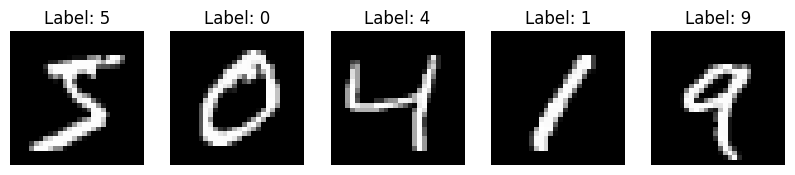

In [1]:

import matplotlib.pyplot as plt

import torchvision.transforms as transforms

from torchvision.datasets import MNIST


transform = transforms.Compose([
    transforms.ToTensor(),                     # из [0,255] в [0,1]
    transforms.Normalize((0.1307,), (0.3081,)) # нормализация (mean=0.1307,std=0.3081)
])


train_data = MNIST(root='./data', train=True, download=True, transform=transform)
test_data  = MNIST(root='./data', train=False, download=True, transform=transform)


# Блок кода, отвечающий за визуализацию, его редактировать не надо.
fig, axes = plt.subplots(1, 5, figsize=(10,2))
for i, ax in enumerate(axes):
    img, label = train_data[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.show()

images.shape: torch.Size([64, 1, 28, 28])
labels.shape: torch.Size([64])
Метка первого изображения в батче: 0


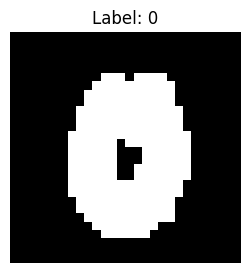

In [2]:

from torch.utils.data import DataLoader

from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.ToTensor(),                     # из [0,255] в [0,1]
    transforms.Normalize((0.1307,), (0.3081,)) # нормализация (mean=0.1307,std=0.3081)
])


train_data = MNIST(root='./data', train=True, download=True, transform=transform)
test_data  = MNIST(root='./data', train=False, download=True, transform=transform)


train_size = int(0.8 * len(train_data))
val_size   = len(train_data) - train_size

train_data, val_data = random_split(train_data, [train_size, val_size])


train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=64, shuffle=False)


images, labels = next(iter(train_loader))


# Печатаем формы тензоров
print("images.shape:", images.shape)   # torch.Size([64, 1, 28, 28])
print("labels.shape:", labels.shape)   # torch.Size([64])


# Выведем метку первого изображения
first_label = labels[0].item()
print("Метка первого изображения в батче:", first_label)


# Отобразим само первое изображение
plt.figure(figsize=(3,3))
plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(f"Label: {first_label}")
plt.axis('off')
plt.show()

In [3]:
import torch
import torch.nn as nn
import torch.nn.init as init
import torchvision
from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader


# Готовим данные
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


dataset = MNIST(root='./data', train=True, download=True, transform=transform)
train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=64, shuffle=False)
images, labels = next(iter(train_loader))


# Определяем модель через nn.Sequential

model_seq = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)


# Прогон и обучение одного батча
out_seq = model_seq(images)
print("Output shape:", out_seq.shape)   # ожидаем [64, 10]


optimizer = torch.optim.SGD(model_seq.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()


optimizer.zero_grad()
loss = criterion(out_seq, labels)
loss.backward()
optimizer.step()


print("Loss после одного шага:", loss.item())

Output shape: torch.Size([64, 10])
Loss после одного шага: 2.323591947555542


Epoch 1/5 — Loss: 0.3474, Accuracy: 90.23%
Epoch 2/5 — Loss: 0.1467, Accuracy: 95.68%
Epoch 3/5 — Loss: 0.0970, Accuracy: 97.05%
Epoch 4/5 — Loss: 0.0734, Accuracy: 97.75%
Epoch 5/5 — Loss: 0.0561, Accuracy: 98.28%
Test Loss: 0.0885, Test Accuracy: 97.29%


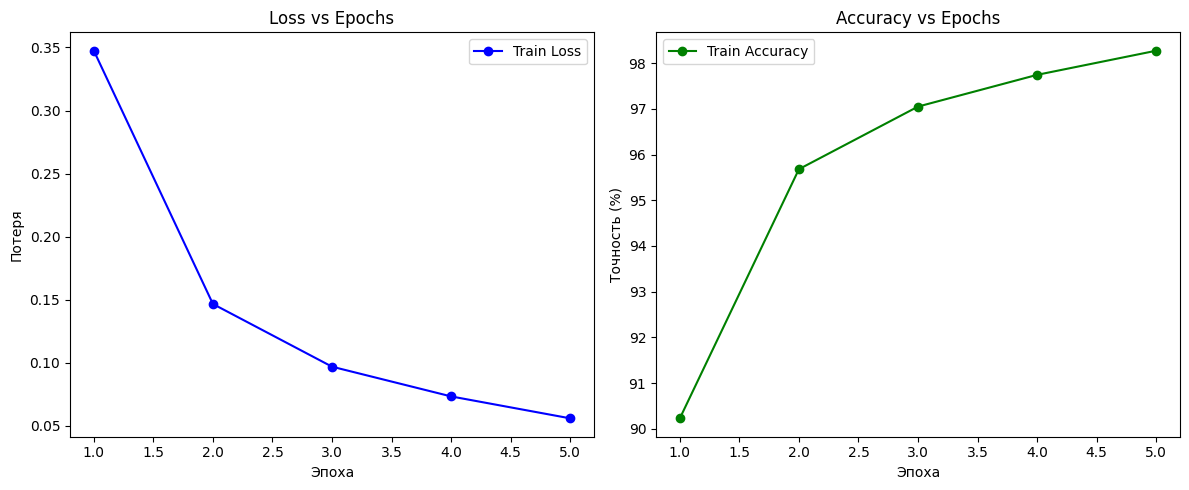

In [4]:
import torch

import torch.nn as nn

import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import datasets, transforms

import matplotlib.pyplot as plt


# Определяем модель AdvancedMNISTMLPList (из прошлого урока)
class AdvancedMNISTMLPList(nn.Module):
    def __init__(self):
        super(AdvancedMNISTMLPList, self).__init__()
        self.layers = nn.ModuleList([
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        ])
    def forward(self, x):
        x = x.view(-1, 28*28)  # раскладываем картинку в вектор
        for layer in self.layers:
            x = layer(x)
        return x


model = AdvancedMNISTMLPList()


# Загружаем данные MNIST (тренировочный и тестовый набор)
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=False, transform=transform)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=1000, shuffle=False)


# Инициализируем функцию потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# Цикл обучения
num_epochs = 5

train_losses = []
train_accuracies = []


for epoch in range(num_epochs):
    model.train()  # перевод модели в режим обучения
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Проход по всем батчам трен.набора
    for images, labels in train_loader:


        # Прямой проход
        outputs = model(images)             # выходы - логиты [batch, 10]
        loss = criterion(outputs, labels)   # вычисляем потерю


        # Обратный проход и оптимизация
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        # Накопление статистики для метрик
        running_loss += loss.item()         # суммируем loss
        _, predicted = outputs.max(1)       # индекс максимальной логиты = предсказанный класс
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()


    # Средние значения по эпохе
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100.0 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)


    # Выводим информацию по эпохе
    print(f'Epoch {epoch+1}/{num_epochs} — Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')


# Оценка на тестовом наборе
model.eval()  # режим оценки
test_loss = 0.0

correct = 0

total = 0

all_preds = []
all_labels = []


with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


test_loss = test_loss / len(test_loader)
test_accuracy = 100.0 * correct / total

print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')


# Построение графиков потерь и точности
epochs = range(1, num_epochs+1)
plt.figure(figsize=(12,5))


plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, marker='o', color='blue', label='Train Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Эпоха')
plt.ylabel('Потеря')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, marker='o', color='green', label='Train Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Эпоха')
plt.ylabel('Точность (%)')
plt.legend()


plt.tight_layout()
plt.show()

MLP_1layer Epoch 1/5 - Train Loss: 0.4256, Val Loss: 0.2626, Val Acc: 92.46%
MLP_1layer Epoch 2/5 - Train Loss: 0.2481, Val Loss: 0.2447, Val Acc: 92.79%
MLP_1layer Epoch 3/5 - Train Loss: 0.2181, Val Loss: 0.2087, Val Acc: 93.98%
MLP_1layer Epoch 4/5 - Train Loss: 0.1993, Val Loss: 0.2002, Val Acc: 94.03%
MLP_1layer Epoch 5/5 - Train Loss: 0.1869, Val Loss: 0.1972, Val Acc: 94.27%


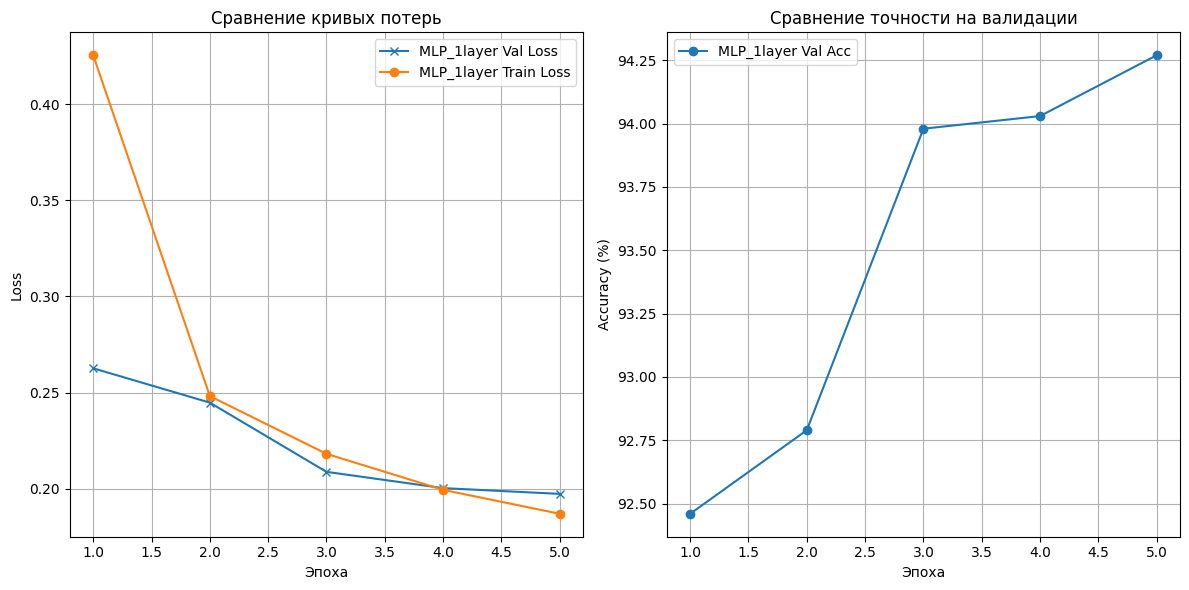

In [5]:

import torch

import torch.nn as nn

import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import datasets, transforms

import matplotlib.pyplot as plt


# Подготовка данных MNIST

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
val_dataset   = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=1000, shuffle=False)


# Последовательность самой модели
model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 16),
        nn.ReLU(),
        nn.Linear(16, 10)
    )


# Название модели для отображения графиков и логирования
name = 'MLP_1layer'


num_epochs = 5

hist = {name: {'train_loss': [], 'val_loss': [], 'val_acc': []} }


criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)


for epoch in range(1, num_epochs + 1):
    # Обучение
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_train_loss = running_loss / len(train_loader)
    # Добавляем потерю для графика
    hist[name]['train_loss'].append(epoch_train_loss)


    # Валидация
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)


    # В этот раз посчитаем валидацию на каждой эпохе обучения
    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc  = 100.0 * correct / total
    # Добавляем потерю для графика
    hist[name]['val_loss'].append(epoch_val_loss)
    # Добавляем точность для графика
    hist[name]['val_acc'].append(epoch_val_acc)

    print(f"{name} Epoch {epoch}/{num_epochs} - "
            f"Train Loss: {epoch_train_loss:.4f}, "
            f"Val Loss: {epoch_val_loss:.4f}, "
            f"Val Acc: {epoch_val_acc:.2f}%")


# Визуализация истории обучения (пример для loss)
plt.figure(figsize=(12, 6))


# Потеря
plt.subplot(1, 2, 1)
epochs = range(1, num_epochs + 1)
plt.plot(epochs, hist[name]['val_loss'],   marker='x', label=f"{name} Val Loss")
plt.plot(epochs, hist[name]['train_loss'], marker='o', label=f"{name} Train Loss",)
plt.title("Сравнение кривых потерь")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)


# Точность
plt.subplot(1, 2, 2)


epochs = range(1, num_epochs + 1)
plt.plot(epochs, hist[name]['val_acc'], marker='o', label=f"{name} Val Acc")
plt.title("Сравнение точности на валидации")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

MLP_2layer Epoch 1/5 - Train Loss: 0.2696, Val Loss: 0.1303, Val Acc: 96.04%
MLP_2layer Epoch 2/5 - Train Loss: 0.1108, Val Loss: 0.0999, Val Acc: 96.85%
MLP_2layer Epoch 3/5 - Train Loss: 0.0819, Val Loss: 0.0886, Val Acc: 97.32%
MLP_2layer Epoch 4/5 - Train Loss: 0.0619, Val Loss: 0.0735, Val Acc: 97.58%
MLP_2layer Epoch 5/5 - Train Loss: 0.0480, Val Loss: 0.0918, Val Acc: 97.41%


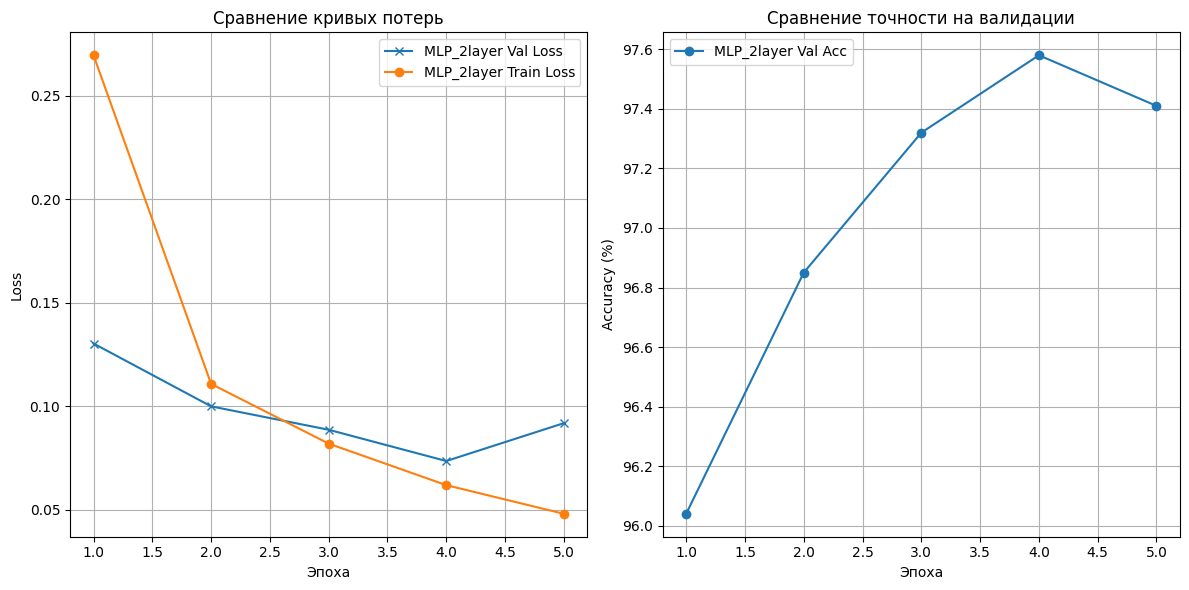

In [6]:
# Последовательность самой модели

model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )


# Название модели для отображения графиков и логирования
name = 'MLP_2layer'


num_epochs = 5

hist = {name: {'train_loss': [], 'val_loss': [], 'val_acc': []} }


criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)


for epoch in range(1, num_epochs + 1):
    # Обучение
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_train_loss = running_loss / len(train_loader)
    # Добавляем потерю для графика
    hist[name]['train_loss'].append(epoch_train_loss)


    # Валидация
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)


    # В этот раз посчитаем валидацию на каждой эпохе обучения
    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc  = 100.0 * correct / total
    # Добавляем потерю для графика
    hist[name]['val_loss'].append(epoch_val_loss)
    # Добавляем точность для графика
    hist[name]['val_acc'].append(epoch_val_acc)


    print(f"{name} Epoch {epoch}/{num_epochs} - "
            f"Train Loss: {epoch_train_loss:.4f}, "
            f"Val Loss: {epoch_val_loss:.4f}, "
            f"Val Acc: {epoch_val_acc:.2f}%")



# Визуализация истории обучения (пример для loss)
plt.figure(figsize=(12, 6))


# Потеря
plt.subplot(1, 2, 1)
epochs = range(1, num_epochs + 1)
plt.plot(epochs, hist[name]['val_loss'],   marker='x', label=f"{name} Val Loss")
plt.plot(epochs, hist[name]['train_loss'], marker='o', label=f"{name} Train Loss",)
plt.title("Сравнение кривых потерь")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)


# Точность
plt.subplot(1, 2, 2)


epochs = range(1, num_epochs + 1)
plt.plot(epochs, hist[name]['val_acc'], marker='o', label=f"{name} Val Acc")
plt.title("Сравнение точности на валидации")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

MLP_3layer Epoch 1/5 - Train Loss: 0.3404, Val Loss: 0.1256, Val Acc: 96.28%
MLP_3layer Epoch 2/5 - Train Loss: 0.1873, Val Loss: 0.1035, Val Acc: 97.03%
MLP_3layer Epoch 3/5 - Train Loss: 0.1531, Val Loss: 0.0906, Val Acc: 97.31%
MLP_3layer Epoch 4/5 - Train Loss: 0.1323, Val Loss: 0.0859, Val Acc: 97.44%
MLP_3layer Epoch 5/5 - Train Loss: 0.1201, Val Loss: 0.0762, Val Acc: 97.57%


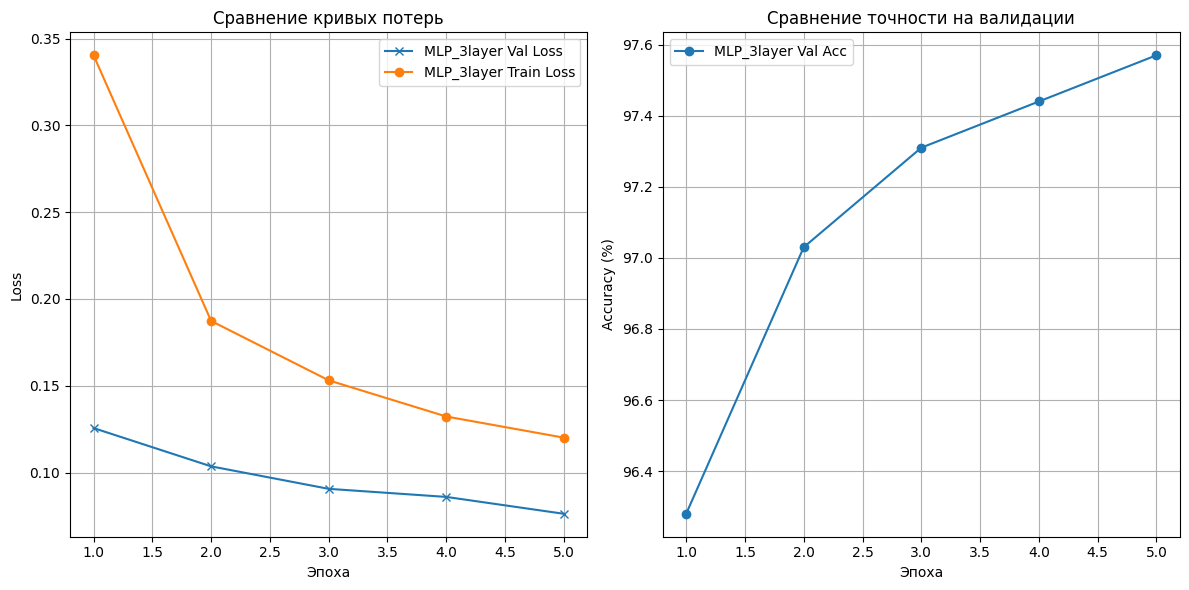

In [7]:
# Последовательность самой модели
model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )


# Название модели для отображения графиков и логирования
name = 'MLP_3layer'


num_epochs = 5

hist = {name: {'train_loss': [], 'val_loss': [], 'val_acc': []} }


criterion = nn.CrossEntropyLoss()


optimizer = optim.Adam(model.parameters(), lr=0.001)


for epoch in range(1, num_epochs + 1):
    # Обучение
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_train_loss = running_loss / len(train_loader)
    # Добавляем потерю для графика
    hist[name]['train_loss'].append(epoch_train_loss)


    # Валидация
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)


    # В этот раз посчитаем валидацию на каждой эпохе обучения
    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc  = 100.0 * correct / total
    # Добавляем потерю для графика
    hist[name]['val_loss'].append(epoch_val_loss)
    # Добавляем точность для графика
    hist[name]['val_acc'].append(epoch_val_acc)

    print(f"{name} Epoch {epoch}/{num_epochs} - "
            f"Train Loss: {epoch_train_loss:.4f}, "
            f"Val Loss: {epoch_val_loss:.4f}, "
            f"Val Acc: {epoch_val_acc:.2f}%")


# Визуализация истории обучения (пример для loss)
plt.figure(figsize=(12, 6))


# Потеря
plt.subplot(1, 2, 1)
epochs = range(1, num_epochs + 1)
plt.plot(epochs, hist[name]['val_loss'],   marker='x', label=f"{name} Val Loss")
plt.plot(epochs, hist[name]['train_loss'], marker='o', label=f"{name} Train Loss",)
plt.title("Сравнение кривых потерь")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)


# Точность
plt.subplot(1, 2, 2)


epochs = range(1, num_epochs + 1)
plt.plot(epochs, hist[name]['val_acc'], marker='o', label=f"{name} Val Acc")
plt.title("Сравнение точности на валидации")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()